**Hey there,**

Just completed my first end-to-end machine learning project which I built by hand.

It's a satellite image classifier using transfer learning: ResNet50 (pretrained on ImageNet), fine-tuned on the EuroSAT dataset in PyTorch, sorting satellite imagery into 10 land-cover types at around 96% test accuracy. I evaluated it with a full per-class report and a confusion matrix to understand where it does well and where it still gets confused.

I'll be honest about the process: the idea came from a tutorial I found online, and I leaned on AI to help with debugging. But I typed every line myself, worked through the errors, and made sure I understood what each part actually does.

It's not groundbreaking, but it's a real start, and I learned a lot building it. Looking forward to taking it further.

Part of the journey is the start.

In [1]:
import torch as to

In [2]:
from torchvision.datasets import EuroSAT
dataset = EuroSAT(root='data', download=True)

In [3]:
print("Total images:", len(dataset))
print("Classes:", dataset.classes)

Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [4]:
print("PyTorch version:", to.__version__)
print("GPU available:", to.cuda.is_available())
print("GPU name:", to.cuda.get_device_name(0) if to.cuda.is_available() else "NO GPU — re-check Runtime settings")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [5]:
from torchvision import transforms as t
from torch.utils.data import random_split as rs,Subset as s,DataLoader as dl
mean =[0.485,0.456,0.406]
std =[0.229,0.224,0.225]
traintf = t.Compose([
    t.Resize((224,224)),
    t.RandomHorizontalFlip(),
    t.RandomVerticalFlip(),
    t.ToTensor(),
    t.Normalize(mean,std)
])
evaltf=t.Compose([
    t.Resize((224,224)),
    t.ToTensor(),
    t.Normalize(mean,std)
])

In [6]:
trainview=EuroSAT(root='data',transform=traintf)
evalview=EuroSAT(root='data',transform=evaltf)

In [7]:
from torch.utils.data.dataset import random_split
n=len(trainview)
trn=int(0.8*n)
valn=int(0.1*n)
tstn= n-trn-valn
g=to.Generator().manual_seed(42)
trid,vlid,tstid=random_split(range(n),[trn,valn,tstn], generator =g)
trnset=s(trainview,trid.indices)
vlset=s(evalview,vlid.indices)
tstset=s(evalview,tstid.indices)
trainloader=dl(trnset,batch_size=32,shuffle=True)
evalloader=dl(vlset,batch_size=32,shuffle=False)
testloader=dl(tstset,batch_size=32,shuffle=False)

In [8]:
print(f"Train: {len(trnset)}")
print(f"Validation: {len(vlset)}")
print(f"Test: {len(tstset)}")

Train: 21600
Validation: 2700
Test: 2700


In [9]:
import torch.nn as nn
from torchvision.models import resnet50 as rs5,ResNet50_Weights as rsw
rsmodel = rs5(weights=rsw.DEFAULT)
for param in rsmodel.parameters():
  param.requires_grad=False
numfeatures=rsmodel.fc.in_features
rsmodel.fc=nn.Linear(numfeatures,10)
rsmodel=rsmodel.to('cuda')
print("Model is READY, for you.")
print("New Final Layer: ", rsmodel.fc)

Model is READY, for you.
New Final Layer:  Linear(in_features=2048, out_features=10, bias=True)


In [10]:
import torch.optim as op
from tqdm import tqdm as tq
criterion=nn.CrossEntropyLoss()
optimzer=op.Adam(rsmodel.fc.parameters(),lr=0.001)
ne=10
best=0.0
for epoch in range(ne):
  rsmodel.train()
  rl=0.0
  for img, lbl in tq(trainloader, desc = f"Epoch{epoch+1}/{ne}[train]"):
    img,lbl=img.to('cuda'),lbl.to('cuda')
    optimzer.zero_grad()
    output=rsmodel(img)
    loss=criterion(output,lbl)
    loss.backward()
    optimzer.step()
    rl += loss.item()
  rsmodel.eval()
  correct=0
  total=0
  with to.no_grad():
    for img, lbl in evalloader:
            img, lbl = img.to('cuda'), lbl.to('cuda')
            outputs = rsmodel(img)
            _, predicted = to.max(outputs, 1)
            total += lbl.size(0)
            correct += (predicted == lbl).sum().item()
    valacc = correct / total
    print(f"Epoch {epoch+1}/{ne} \n loss: {rl/len(trainloader):.4f} \n val accuracy: {valacc:.4f}")
    if valacc > best:
        best = valacc
        to.save(rsmodel.state_dict(), 'best_model.pth')
        print(f"new best saved ({valacc:.4f})")
print(f"\n Done. Best validation accuracy: {best:.4f}")

Epoch1/10[train]: 100%|██████████| 675/675 [01:52<00:00,  6.02it/s]


Epoch 1/10 
 loss: 0.6156 
 val accuracy: 0.9052
new best saved (0.9052)


Epoch2/10[train]: 100%|██████████| 675/675 [01:49<00:00,  6.14it/s]


Epoch 2/10 
 loss: 0.3303 
 val accuracy: 0.9244
new best saved (0.9244)


Epoch3/10[train]: 100%|██████████| 675/675 [01:50<00:00,  6.10it/s]


...

Epoch 8/10 
 loss: 0.1960 
 val accuracy: 0.9430
new best saved (0.9430)


Epoch9/10[train]: 100%|██████████| 675/675 [01:50<00:00,  6.11it/s]


Epoch 9/10 
 loss: 0.1960 
 val accuracy: 0.9393


Epoch10/10[train]: 100%|██████████| 675/675 [01:53<00:00,  5.94it/s]


Epoch 10/10 
 loss: 0.1816 
 val accuracy: 0.9422

 Done. Best validation accuracy: 0.9430


In [11]:
for param in rsmodel.parameters():
  param.requires_grad=True
optimizer=op.Adam(rsmodel.parameters(), lr=0.0001)
fte=5
for epoch in range(fte):
  rsmodel.train()
  rl=0.0
  for img, lbl in tq(trainloader, desc = f"Epoch{epoch+1}/{fte}[train]"):
    img,lbl=img.to('cuda'),lbl.to('cuda')
    optimizer.zero_grad()
    output=rsmodel(img)
    loss=criterion(output,lbl)
    loss.backward()
    optimizer.step()
    rl += loss.item()
  rsmodel.eval()
  correct=0
  total=0
  with to.no_grad():
    for img, lbl in evalloader:
            img, lbl = img.to('cuda'), lbl.to('cuda')
            output = rsmodel(img)
            _, predicted = to.max(output, 1)
            total += lbl.size(0)
            correct += (predicted == lbl).sum().item()
    valacc = correct / total
    print(f"Fine-Tune{epoch+1}/{fte} \n loss: {rl/len(trainloader):.4f} \n val accuracy: {valacc:.4f}")
    if valacc > best:
        best = valacc
        to.save(rsmodel.state_dict(), 'best_model.pth')
        print(f"new best saved ({valacc:.4f})")
print(f"\n Done. Best validation accuracy: {best:.4f}")

Epoch1/5[train]: 100%|██████████| 675/675 [04:30<00:00,  2.50it/s]


Fine-Tune1/5 
 loss: 0.1282 
 val accuracy: 0.9726
new best saved (0.9726)


Epoch2/5[train]: 100%|██████████| 675/675 [04:28<00:00,  2.52it/s]


Fine-Tune2/5 
 loss: 0.0772 
 val accuracy: 0.9759
new best saved (0.9759)


Epoch3/5[train]: 100%|██████████| 675/675 [04:27<00:00,  2.52it/s]


Fine-Tune3/5 
 loss: 0.0489 
 val accuracy: 0.9804
new best saved (0.9804)


Epoch4/5[train]: 100%|██████████| 675/675 [04:27<00:00,  2.52it/s]


Fine-Tune4/5 
 loss: 0.0402 
 val accuracy: 0.9763


Epoch5/5[train]: 100%|██████████| 675/675 [04:28<00:00,  2.51it/s]


Fine-Tune5/5 
 loss: 0.0374 
 val accuracy: 0.9793

 Done. Best validation accuracy: 0.9804


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
rsmodel.load_state_dict(to.load('best_model.pth'))
rsmodel.eval()
allpreds=[]
alllabels=[]
with to.no_grad():
    for img, lbl in testloader:
        img=img.to('cuda')
        outputs=rsmodel(img)
        _, predicted=to.max(outputs,1)
        allpreds.extend(predicted.cpu().numpy())
        alllabels.extend(lbl.numpy())
cn=dataset.classes
print(classification_report(alllabels, allpreds, target_names=cn, digits=4))

                      precision    recall  f1-score   support

          AnnualCrop     0.9607    0.9767    0.9686       300
              Forest     1.0000    0.9933    0.9966       297
HerbaceousVegetation     0.9800    0.9735    0.9767       302
             Highway     0.9774    0.9665    0.9720       269
          Industrial     0.9659    0.9922    0.9789       257
             Pasture     0.9833    0.9465    0.9646       187
       PermanentCrop     0.9542    0.9843    0.9690       254
         Residential     0.9967    0.9682    0.9822       314
               River     0.9718    0.9837    0.9777       245
             SeaLake     0.9927    0.9927    0.9927       275

            accuracy                         0.9785      2700
           macro avg     0.9783    0.9778    0.9779      2700
        weighted avg     0.9788    0.9785    0.9785      2700



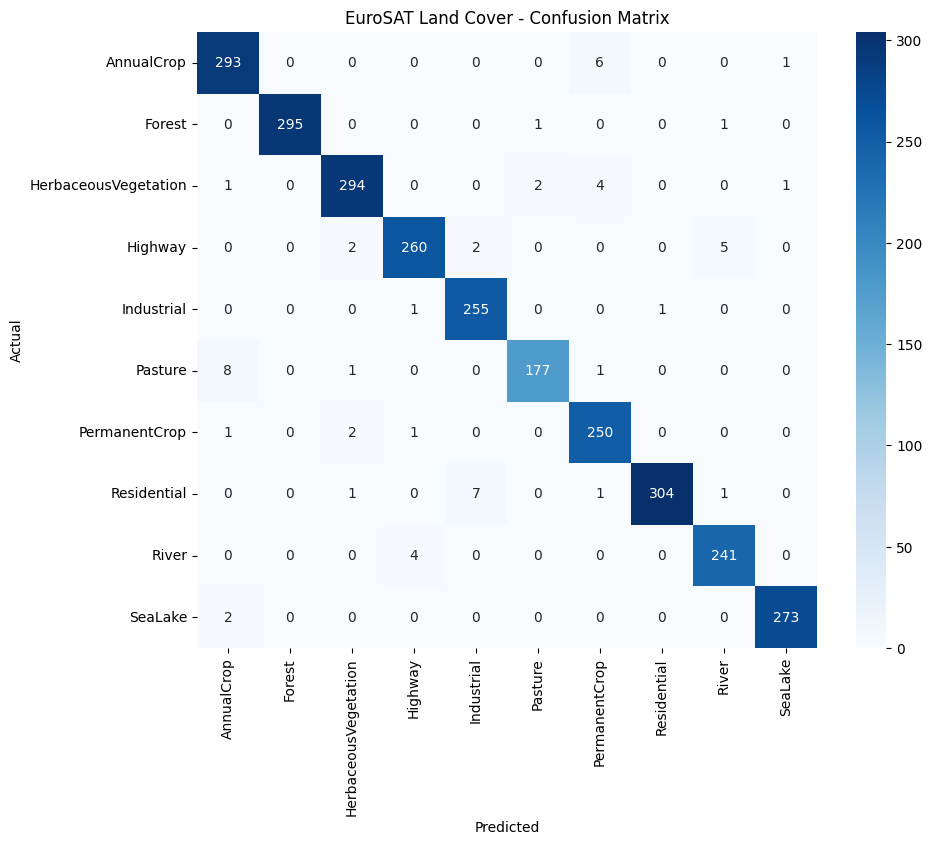

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(alllabels, allpreds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=cn, yticklabels=cn, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EuroSAT Land Cover - Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
from google.colab import files as f
f.download('best_model.pth')
f.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>